# 07 — Memory Model & Spill

**Concept:** Every executor is a JVM process with a fixed heap. Spark divides that heap into three regions — user code, a storage pool (cache), and an execution pool (shuffle, sort, join). When an operation needs more execution memory than is available, Spark spills intermediate data to local disk. When the JVM spends too much time reclaiming objects, GC pauses inflate task duration. Understanding this model is the prerequisite for diagnosing the three most common resource failures in production: OOM, disk spill, and GC overhead.

**Core interview question:** *“A task shows high GC time and disk spill. What is the root cause?”*

## What you will observe
1. **Memory layout in numbers** — convert the three config fractions into actual byte allocations for a running executor.
2. **Execution memory consumers** — which operations (sort, hash aggregate, shuffle write, sort-merge join) draw from the execution pool and appear in `explain()`.
3. **Storage memory** — how `.cache()` and broadcast variables draw from the storage pool.
4. **Unified memory model** — execution can borrow from storage under pressure, evicting cached blocks.
5. **Disk spill** — force a sort to exhaust execution memory and read the `Shuffle Spill (Disk)` column in Task Metrics.
6. **GC pressure** — contrast a Python UDF (heap object overhead) against a native Spark function; understand the cost of crossing the JVM–Python boundary.
7. **OOM patterns** — executor heap OOM vs driver OOM vs overhead OOM, and how to diagnose each from the Spark UI and executor logs.

## Executor JVM memory map

```
spark.executor.memory = 2g  (the JVM heap Spark requests from the cluster manager)
spark.executor.memoryOverhead = 384m  (off-heap: Python workers, Netty buffers, native memory)

┌────────────────────────────────────────────┐  Total container = 2g + 384m = ~2.4 GB
│  JVM Heap  (spark.executor.memory = 2048 MB)                         │
│                                                                      │
│  ┌──────────────────────────────────────────┐                │
│  │  Reserved  (300 MB, hardcoded)                          │                │
│  └──────────────────────────────────────────┘                │
│                                                                      │
│  Usable heap = 2048 - 300 = 1748 MB                                  │
│                                                                      │
│  ┌──────────────────────────────────────────┐                │
│  │  User memory  (40% of usable = ~699 MB)                 │                │
│  │  (1 - spark.memory.fraction) = 0.4 × 1748               │                │
│  │  UDFs, internal data structures, user objects            │                │
│  └──────────────────────────────────────────┘                │
│                                                                      │
│  ┌──────────────────────────────────────────┐                │
│  │  Spark Managed Pool (60% of usable = ~1049 MB)          │                │
│  │  spark.memory.fraction = 0.6 × 1748                      │                │
│  │                                                         │                │
│  │  ┌──────────────────────────────────────┐        │                │
│  │  │  Storage pool  (50% × Spark pool = ~524 MB)  │        │                │
│  │  │  spark.memory.storageFraction = 0.5            │        │                │
│  │  │  Cached RDDs, broadcast variables               │        │                │
│  │  └──────────────────────────────────────┘        │                │
│  │  ┌──────────────────────────────────────┐        │                │
│  │  │  Execution pool (50% × Spark pool = ~524 MB) │        │                │
│  │  │  Shuffles, sorts, joins, aggregations           │        │                │
│  │  │  ← spill to disk when this is exhausted        │        │                │
│  │  └──────────────────────────────────────┘        │                │
│  └──────────────────────────────────────────┘                │
└────────────────────────────────────────────┘

Off-heap (outside the JVM garbage collector):
┌────────────────────────────────────────────┐
│  memoryOverhead = max(executor_memory × 0.1, 384 MB)             │
│  Python worker processes (PySpark), Netty shuffle buffers,       │
│  native JVM memory (thread stacks, JIT compiled code)            │
└────────────────────────────────────────────┘
```

## Key configuration parameters

| Config | Default | Controls |
|---|---|---|
| `spark.executor.memory` | `1g` | Total JVM heap per executor |
| `spark.executor.memoryOverhead` | `max(mem×0.1, 384m)` | Off-heap per executor (Python, Netty) |
| `spark.memory.fraction` | `0.6` | Share of usable heap for Spark managed pool |
| `spark.memory.storageFraction` | `0.5` | Initial storage share within the Spark pool |
| `spark.memory.offHeap.enabled` | `false` | Enable Tungsten off-heap execution memory |
| `spark.memory.offHeap.size` | `0` | Size of Tungsten off-heap pool if enabled |

## Unified memory model (Spark 1.6+)

Before Spark 1.6, execution and storage had **fixed** boundaries. After 1.6, they share the Spark managed pool with soft boundaries:

- **Execution borrows from storage:** if execution needs more memory, it can evict cached blocks to free space in the storage pool. Evicted blocks are re-computed from lineage on the next access.
- **Storage borrows from execution:** storage can expand into unused execution space, but **cannot evict in-use execution data**. If execution needs the space back, storage must yield.
- **The storage floor:** `spark.memory.storageFraction` defines the minimum guaranteed storage space that execution cannot evict. Only blocks *above* this floor are evictable.

**Implication:** a large cache can be silently evicted mid-job if a shuffle or sort needs the execution pool to grow. The cache is not permanent — it is an optimization that Spark may undo under pressure.

<img src="resources/executor_jvm_memory_map.svg" width="900" alt="Executor JVM Memory Map"/>

In [48]:
import sys
import os
import random
import time
from pathlib import Path

sys.path.append(str(Path().absolute().parent))

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
os.environ.setdefault("HADOOP_HOME", r"C:\hadoop")
os.environ["PATH"] = r"C:\hadoop\bin" + os.pathsep + os.environ.get("PATH", "")

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField, IntegerType, StringType, DoubleType, LongType
)

spark = (
    SparkSession.builder
    .master("local[4]")
    .appName("07-memory-model-and-spill")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.shuffle.partitions", "200")
    .config("spark.memory.fraction", "0.6")
    .config("spark.memory.storageFraction", "0.5")
    .config("spark.python.worker.reuse", "true")
    .config("spark.sql.execution.arrow.pyspark.enabled", "false")
    # Remove this block once the spill section is complete. It is only here to make the spill more likely to happen.
    # .config("spark.memory.fraction", "0.005")      # only 10% of usable heap → tiny execution pool
    # .config("spark.sql.shuffle.partitions", "4") # few large tasks → more pressure per task
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

print(f"Spark {spark.version}  —  UI: http://localhost:4040")
print(f"memory.fraction       : {spark.conf.get('spark.memory.fraction')}")
print(f"memory.storageFraction: {spark.conf.get('spark.memory.storageFraction')}")
print(f"shuffle.partitions    : {spark.conf.get('spark.sql.shuffle.partitions')}")
print(f"memory.fraction: {spark.conf.get('spark.memory.fraction')}")

Spark 3.5.8  —  UI: http://localhost:4040
memory.fraction       : 0.6
memory.storageFraction: 0.5
shuffle.partitions    : 200
memory.fraction: 0.6


In [47]:
spark.stop()

In [50]:
random.seed(42)

# 500 000 orders — large enough to exercise execution memory visibly
N = 500_000
orders_data = [
    (
        i,
        random.randint(1, 10_000),   # customer_id  (10k unique values)
        random.randint(1, 500),      # product_id   (500 unique values)
        random.choice(["US", "DE", "GB", "FR", "JP", "BR", "IN", "CA", "AU", "MX"]),
        round(random.uniform(1.0, 5000.0), 2),  # amount
        random.randint(1, 100),      # quantity
        f"notes_{random.randint(1, 1000)}",      # padding column
    )
    for i in range(1, N + 1)
]

schema = StructType([
    StructField("order_id",    IntegerType(), False),
    StructField("customer_id", IntegerType(), True),
    StructField("product_id",  IntegerType(), True),
    StructField("region",      StringType(),  True),
    StructField("amount",      DoubleType(),  True),
    StructField("quantity",    IntegerType(), True),
    StructField("notes",       StringType(),  True),
])

orders = spark.createDataFrame(orders_data, schema=schema)

# Small dimension table for join demos
products = spark.createDataFrame(
    [(i, f"product_{i}", f"cat_{(i % 10) + 1}", round(random.uniform(5.0, 500.0), 2))
     for i in range(1, 501)],
    ["product_id", "product_name", "category", "list_price"]
)

print(f"orders   : {N:,} rows, {len(orders.columns)} columns")
print(f"products : {products.count()} rows")
print("Schema:", orders.schema.simpleString())

orders   : 500,000 rows, 7 columns
products : 500 rows
Schema: struct<order_id:int,customer_id:int,product_id:int,region:string,amount:double,quantity:int,notes:string>


## 1. Reading the memory map from live config values

The three config fractions combine to give exact byte allocations for every executor. Knowing these numbers lets you answer "why does the job spill?" without guesswork.

**Calculation chain:**
```
heap                 = spark.executor.memory
reserved             = 300 MB  (hardcoded in Spark source)
usable               = heap - reserved
spark_pool           = usable × spark.memory.fraction
user_memory          = usable - spark_pool
storage_pool_initial = spark_pool × spark.memory.storageFraction
execution_pool_init  = spark_pool × (1 - spark.memory.storageFraction)
```

> In local mode `spark.executor.memory` is a soft limit — the actual JVM heap is set by `-Xmx` in the Java launch arguments. For this notebook we compute the allocation from the configured values and relate them to what the Spark UI Executors tab shows on a real cluster.

In [4]:
# Compute actual byte allocations from the running config
RESERVED_MB = 300

def parse_mb(conf_val: str) -> float:
    """Convert a Spark memory string (e.g. '1g', '512m') to MB."""
    val = conf_val.strip().lower()
    if val.endswith("g"):  return float(val[:-1]) * 1024
    if val.endswith("m"):  return float(val[:-1])
    if val.endswith("k"):  return float(val[:-1]) / 1024
    return float(val) / (1024 * 1024)

executor_mem_mb  = parse_mb(spark.conf.get("spark.executor.memory", "1g"))
mem_fraction     = float(spark.conf.get("spark.memory.fraction", "0.6"))
storage_fraction = float(spark.conf.get("spark.memory.storageFraction", "0.5"))

usable_mb       = executor_mem_mb - RESERVED_MB
spark_pool_mb   = usable_mb * mem_fraction
user_memory_mb  = usable_mb - spark_pool_mb
storage_init_mb = spark_pool_mb * storage_fraction
exec_init_mb    = spark_pool_mb * (1 - storage_fraction)

# Overhead: max(executor_memory * 0.1, 384 MB)
overhead_mb = max(executor_mem_mb * 0.1, 384.0)

print("Memory allocation for the configured executor:")
print(f"  spark.executor.memory     : {executor_mem_mb:>8.0f} MB")
print(f"  Reserved (hardcoded)      : {RESERVED_MB:>8d} MB")
print(f"  Usable heap               : {usable_mb:>8.0f} MB")
print()
print(f"  User memory ({1-mem_fraction:.0%} of usable) : {user_memory_mb:>8.0f} MB  ← UDFs, Spark internals")
print(f"  Spark managed pool ({mem_fraction:.0%})    : {spark_pool_mb:>8.0f} MB  ← execution + storage")
print(f"    Storage pool (initial)  : {storage_init_mb:>8.0f} MB  ← cache, broadcast variables")
print(f"    Execution pool (initial): {exec_init_mb:>8.0f} MB  ← shuffles, sorts, joins")
print(f"    (pools can borrow from each other — unified memory model)")
print()
print(f"  memoryOverhead (off-heap) : {overhead_mb:>8.0f} MB  ← Python workers, Netty")
print(f"  Total container memory    : {executor_mem_mb + overhead_mb:>8.0f} MB")
print()
print(f"Key ratio: execution pool starts at {exec_init_mb/executor_mem_mb:.1%} of total executor memory.")
print("A sort or join whose per-task working set exceeds this size will spill to disk.")

Memory allocation for the configured executor:
  spark.executor.memory     :     1024 MB
  Reserved (hardcoded)      :      300 MB
  Usable heap               :      724 MB

  User memory (40% of usable) :      290 MB  ← UDFs, Spark internals
  Spark managed pool (60%)    :      434 MB  ← execution + storage
    Storage pool (initial)  :      217 MB  ← cache, broadcast variables
    Execution pool (initial):      217 MB  ← shuffles, sorts, joins
    (pools can borrow from each other — unified memory model)

  memoryOverhead (off-heap) :      384 MB  ← Python workers, Netty
  Total container memory    :     1408 MB

Key ratio: execution pool starts at 21.2% of total executor memory.
A sort or join whose per-task working set exceeds this size will spill to disk.


### What to observe

With the default `spark.executor.memory=1g`:
- Usable heap after the 300 MB reserve: **724 MB**
- Spark managed pool (60%): **~434 MB**
- Each pool starts at **~217 MB** (50/50 split)
- The execution pool’s initial size is only **~21% of total executor memory**

**Interview takeaway:** when asked "what percentage of executor memory is available for execution?" the answer is not 100% — it is roughly 20–30% depending on config. The rest goes to the reserved region, user code, storage pool, and off-heap overhead.

**The unified model’s key implication:** if the cache is empty, execution can grow to the full Spark pool (~434 MB). If the cache holds 300 MB of data, execution starts with only 134 MB before it must begin evicting cache blocks. This is why caching speeds up reads but can slow down a subsequent large aggregation — it competes for the same execution pool.

## 2. Execution memory consumers

The execution pool is drained by four categories of operations. Knowing which `explain()` nodes correspond to which consumer lets you predict spill before running a query.

| Operation | `explain()` node | Memory pattern |
|---|---|---|
| Partial aggregation | `HashAggregate(partial)` | Hash map per partition; size ∼ distinct keys × row size |
| Final aggregation | `HashAggregate(final)` | Hash map of merged results; runs post-shuffle |
| Shuffle write | `Exchange hashpartitioning(...)` | Hash/sort buffers per output partition |
| Global sort | `Sort` | External merge sort; writes sorted runs to disk if memory exhausted |
| Sort-merge join | `SortMergeJoin` | Sort on both sides + merge; both sorts can spill independently |
| Broadcast join | `BroadcastHashJoin` | Build side in memory on the driver, then broadcast; uses driver heap |

**Key insight:** `HashAggregate(partial)` runs per partition *before* the shuffle. If a partition has many unique keys and the hash map fills the execution pool, Spark spills the hash map to disk in sorted runs and then merges them — exactly like an external merge sort. The `Shuffle Spill (Memory)` and `Shuffle Spill (Disk)` columns in Task Metrics capture this.

**Operators that do NOT consume execution memory:** `Filter`, `Project`, `Scan`. These process one row at a time and do not maintain per-partition in-memory state proportional to the data size.

In [7]:
# Show execution-memory-consuming operators in explain() output

# Query 1: aggregation — HashAggregate(partial) + Exchange + HashAggregate(final)
agg_query = (
    orders
    .groupBy("customer_id", "region")
    .agg(
        F.sum("amount").alias("total_amount"),
        F.count("order_id").alias("order_count"),
        F.avg("quantity").alias("avg_qty"),
    )
)

print("=== Aggregation plan — execution memory consumers ===")
print("Look for: HashAggregate(partial), Exchange, HashAggregate(final)")
print()
agg_query.explain(mode="extended")

print("\n" + "=" * 60)

# Query 2: global sort — Sort node uses execution memory for external merge sort
sort_query = (
    orders
    .orderBy("amount", ascending=False)
    .limit(100)
)

print()
print("=== Sort plan — external merge sort consumer ===")
print("Look for: Sort, Exchange rangepartitioning")
print()
sort_query.explain(mode="extended")

=== Aggregation plan — execution memory consumers ===
Look for: HashAggregate(partial), Exchange, HashAggregate(final)

== Parsed Logical Plan ==
'Aggregate ['customer_id, 'region], ['customer_id, 'region, sum('amount) AS total_amount#65, count('order_id) AS order_count#67, avg('quantity) AS avg_qty#69]
+- LogicalRDD [order_id#0, customer_id#1, product_id#2, region#3, amount#4, quantity#5, notes#6], false

== Analyzed Logical Plan ==
customer_id: int, region: string, total_amount: double, order_count: bigint, avg_qty: double
Aggregate [customer_id#1, region#3], [customer_id#1, region#3, sum(amount#4) AS total_amount#65, count(order_id#0) AS order_count#67L, avg(quantity#5) AS avg_qty#69]
+- LogicalRDD [order_id#0, customer_id#1, product_id#2, region#3, amount#4, quantity#5, notes#6], false

== Optimized Logical Plan ==
Aggregate [customer_id#1, region#3], [customer_id#1, region#3, sum(amount#4) AS total_amount#65, count(1) AS order_count#67L, avg(quantity#5) AS avg_qty#69]
+- Project [

### What to observe

**Aggregation plan (read bottom to top):**
```
HashAggregate(final)
  +- Exchange hashpartitioning(customer_id, region, 200)
       +- HashAggregate(partial)
            +- LocalTableScan [order_id, customer_id, ...]
```
1. `HashAggregate(partial)` — builds a hash map per task with partial sums. **Execution memory consumer #1.**
2. `Exchange` — shuffles rows by `(customer_id, region)` hash. Writes shuffle files to local disk. **Execution memory consumer #2** (sort buffers for the shuffle write).
3. `HashAggregate(final)` — merges partial results from the shuffle into a final hash map. **Execution memory consumer #3.**

**Sort plan:**
- `Exchange rangepartitioning` samples the data to determine global range boundaries (a hidden sampling job), then redistributes rows
- `Sort` reads its input partition into an in-memory sort buffer; when the buffer fills the execution pool, it writes sorted runs to disk and merges them (external merge sort)

**Rule:** any operator that maintains in-memory state proportional to input size is a potential spill point. Operators that process one row at a time (`Filter`, `Project`, `Scan`) do not consume execution memory and cannot spill.

## 3. Storage memory — cache and broadcast variables

Storage memory holds two types of data:

**1. Cached DataFrames / RDDs**
When you call `.cache()` or `.persist(storageLevel)`, Spark stores the materialized blocks in the storage pool. Each block corresponds to one RDD/DataFrame partition.

**2. Broadcast variables**
When Spark broadcasts a table for a `BroadcastHashJoin`, the broadcast data is stored in the storage pool on every executor. A 100 MB broadcast table consumes 100 MB of storage memory on *each* executor simultaneously.

**Storage levels and their memory cost:**

| Storage level | Memory use | Disk use | CPU cost on read |
|---|---|---|---|
| `MEMORY_ONLY` | Full deserialized objects | None | Low |
| `MEMORY_ONLY_SER` | Compressed byte arrays | None | Deserialize on each read |
| `MEMORY_AND_DISK` | Blocks that fit | Overflow blocks | Low for in-memory blocks |
| `DISK_ONLY` | None | All blocks | Deserialize on every read |
| `_2` suffix (e.g. `MEMORY_AND_DISK_2`) | Caches data as deserialized objects in JVM memory across two different nodes | Double | Network cost on write |

> **PySpark note:** `df.cache()` in PySpark defaults to `MEMORY_AND_DISK`, not `MEMORY_ONLY` as in the Scala API. Verify with `df.storageLevel` after caching.

**`InMemoryTableScan` in the plan:** when Spark reads a cached DataFrame, `explain()` shows `InMemoryTableScan` instead of the original source operator. The absence of the source operator (and potentially of an upstream shuffle) means the stage reads from the storage pool rather than recomputing from scratch.

In [8]:
# Demonstrate how caching changes the physical plan

# Step 1: aggregation WITHOUT cache — Spark reads from LocalTableScan each time
agg_no_cache = (
    orders
    .filter(F.col("region") == "US")
    .groupBy("product_id")
    .agg(F.sum("amount").alias("us_revenue"))
)

print("=== Plan WITHOUT cache ===")
print("Source node: LocalTableScan — Spark reads from the original in-memory DataFrame")
agg_no_cache.explain(mode="simple")

print("\n" + "=" * 60 + "\n")

# Step 2: cache the filtered orders
us_orders = orders.filter(F.col("region") == "US").cache()
_ = us_orders.count()  # materialize the cache (cache() is lazy)

print(f"Cache materialized. Storage level: {us_orders.storageLevel}")
print(f"Cached rows (US only): {us_orders.count():,}")

# Step 3: same aggregation ON the cached DataFrame
agg_with_cache = (
    us_orders
    .groupBy("product_id")
    .agg(F.sum("amount").alias("us_revenue"))
)

print()
print("=== Plan WITH cache ===")
print("Source node: InMemoryTableScan — Spark reads from the storage pool")
agg_with_cache.explain(mode="simple")

=== Plan WITHOUT cache ===
Source node: LocalTableScan — Spark reads from the original in-memory DataFrame
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- HashAggregate(keys=[product_id#2], functions=[sum(amount#4)])
   +- Exchange hashpartitioning(product_id#2, 200), ENSURE_REQUIREMENTS, [plan_id=101]
      +- HashAggregate(keys=[product_id#2], functions=[partial_sum(amount#4)])
         +- Project [product_id#2, amount#4]
            +- Filter (isnotnull(region#3) AND (region#3 = US))
               +- Scan ExistingRDD[order_id#0,customer_id#1,product_id#2,region#3,amount#4,quantity#5,notes#6]




Cache materialized. Storage level: Disk Memory Deserialized 1x Replicated
Cached rows (US only): 50,299

=== Plan WITH cache ===
Source node: InMemoryTableScan — Spark reads from the storage pool
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- HashAggregate(keys=[product_id#2], functions=[sum(amount#4)])
   +- Exchange hashpartitioning(product_id#2, 200), ENSURE_REQUIR

### What to observe

**Without cache:** plan root is `LocalTableScan`. Every `count()` or `show()` re-applies the filter and reads from the original DataFrame object in driver memory.

**With cache:** plan root is `InMemoryTableScan`. The filter has already been applied and the result lives in the storage pool. The `Filter` node above the scan disappears — it is baked into the cached data.

**`storageLevel` output:**
```
StorageLevel(disk=True, memory=True, offHeap=False, deserialized=True, replication=1)
```
This is `MEMORY_AND_DISK`. The `deserialized=True` flag means blocks are stored as Java objects (faster reads, more GC overhead) rather than as serialized byte arrays.

**Spark UI — Storage tab (after materializing):**
- Entry shows `Cached Partitions`, `Fraction Cached`, `Size in Memory`, `Size on Disk`
- A green bar near 100% means all blocks fit in the storage pool
- A blue bar (disk fraction > 0%) means some blocks overflowed to executor local disk

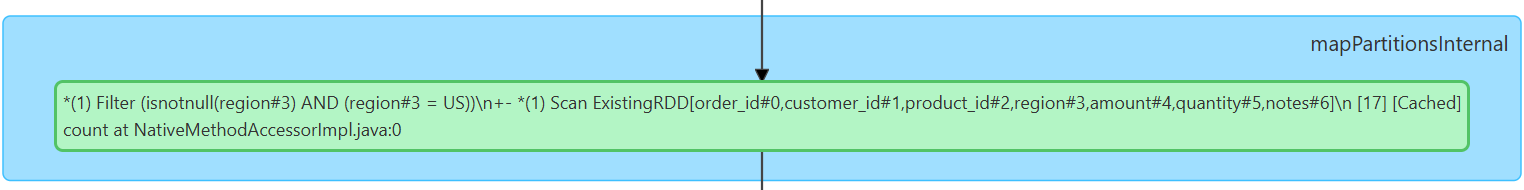

**Spark UI — Stages tab:**
- The second `count()` call (on the cached DataFrame) runs a job that reads from `InMemoryTableScan`
- Compare stage duration: reading from cache is typically 5–20× faster than re-reading and filtering the source

## 4. Unified memory model — pools borrowing from each other

The storage and execution pools share the Spark managed pool. The soft boundary between them means one pool can grow at the expense of the other.

**Borrowing rules:**

```
Scenario A: cache is empty, large aggregation runs
──────────────────────────────────────────────────
Execution expands into the unused storage pool.
Execution can use up to the full Spark managed pool.
No spill occurs even if the working set > initial execution pool.

Scenario B: 400 MB cache present, large sort runs
──────────────────────────────────────────────────
Sort needs 300 MB execution. Execution pool starts at 217 MB.
Storage pool holds 400 MB of cache blocks.
Execution evicts cache blocks above the storage floor until it has enough space.
Those evicted blocks are recomputed from lineage on the next access.
Sort runs without spill. But the next cache read re-runs the original transform.

Scenario C: cache present + execution still exhausted after eviction
──────────────────────────────────────────────────
The storageFraction floor is the minimum storage that execution cannot evict.
If the operation still needs more memory after clearing all evictable cache:
  → SPILL TO DISK.
```

**The storage floor surprise:** `storageFraction` prevents execution from evicting blocks below the floor. It does *not* prevent those blocks from going to disk themselves if the storage pool is too small to hold the entire cache in memory. A 2 GB cache on a 500 MB storage pool stores 500 MB in memory and writes the remaining 1.5 GB to disk automatically (for `MEMORY_AND_DISK`) or drops it silently (for `MEMORY_ONLY`).

<img src="resources/unified_memory_model_scenarios.svg" width="900" alt="Unified Memory Model — Borrowing Scenarios"/>

In [12]:
# Demonstrate unified model: cache a DataFrame, then run a large aggregation.
# Observe whether the cache survives (check the Storage tab before and after).

# Reset: unpersist prior cache
us_orders.unpersist()

# Cache the full orders DataFrame (larger than the US-only subset)
orders_cached = orders.cache()
_ = orders_cached.count()  # materialize
print(f"orders_cached: {orders_cached.count():,} rows")
print(f"Storage level: {orders_cached.storageLevel}")
print()
print(">>> Check the Storage tab in Spark UI NOW. What fraction is in memory?")
print("    If execution pressure is low, near 100% should fit.")
print()

# Run a wide aggregation that needs significant execution memory.
# groupBy on (customer_id, product_id, region) — ~50M combinations in theory;
# actual distinct count is bounded by the data but the hash map is large.
result = (
    orders_cached
    .groupBy("customer_id", "product_id", "region")
    .agg(
        F.sum("amount").alias("total"),
        F.count("*").alias("cnt"),
        F.max("quantity").alias("max_qty"),
        F.min("quantity").alias("min_qty"),
        F.stddev("amount").alias("std_amount"),
    )
    .orderBy("total", ascending=False)
)

print("Running aggregation on cached orders...")
result.show(5)

print()
print(">>> Check the Storage tab again: did the cached fraction decrease?")
print("    If execution evicted cache blocks, the in-memory fraction dropped.")
print()

print("Aggregation plan (InMemoryTableScan = reads from storage pool):")
result.explain(mode="simple")

orders_cached: 500,000 rows
Storage level: Disk Memory Deserialized 1x Replicated

>>> Check the Storage tab in Spark UI NOW. What fraction is in memory?
    If execution pressure is low, near 100% should fit.

Running aggregation on cached orders...
+-----------+----------+------+--------+---+-------+-------+------------------+
|customer_id|product_id|region|   total|cnt|max_qty|min_qty|        std_amount|
+-----------+----------+------+--------+---+-------+-------+------------------+
|        213|       222|    GB|12100.71|  3|     94|     82|1243.8655642391586|
|       7513|       144|    JP|11786.42|  3|     84|     37| 1383.638560366591|
|       2945|       197|    IN| 9999.54|  3|     52|     17|1015.6250301661532|
|       1939|       185|    AU| 9838.35|  2|     31|     22|12.027886347983328|
|       5233|       366|    FR| 9752.59|  2|     36|      5|121.67186383876903|
+-----------+----------+------+--------+---+-------+-------+------------------+
only showing top 5 rows


>>>

In [13]:
orders_cached.unpersist()

DataFrame[order_id: int, customer_id: int, product_id: int, region: string, amount: double, quantity: int, notes: string]

### What to observe

**Before the aggregation (Storage tab):** `orders_cached` shows a high in-memory fraction. All or most partitions are green (in memory). A cached DataFrame **is not sent to all workers**. Instead, the data is partitioned, and each partition is cached locally on the specific worker node where that task runs.

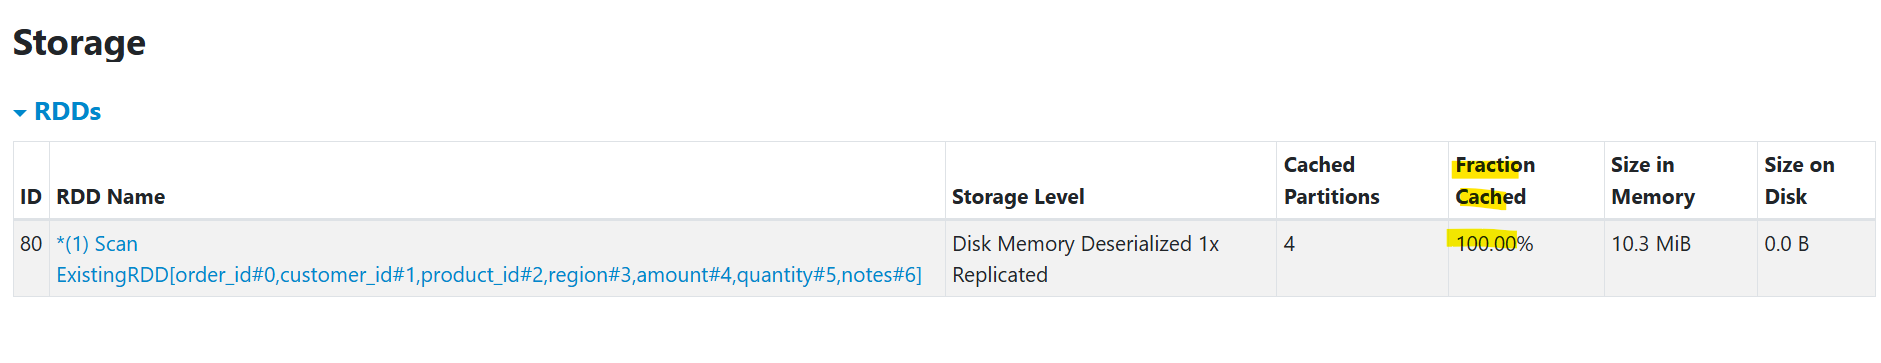
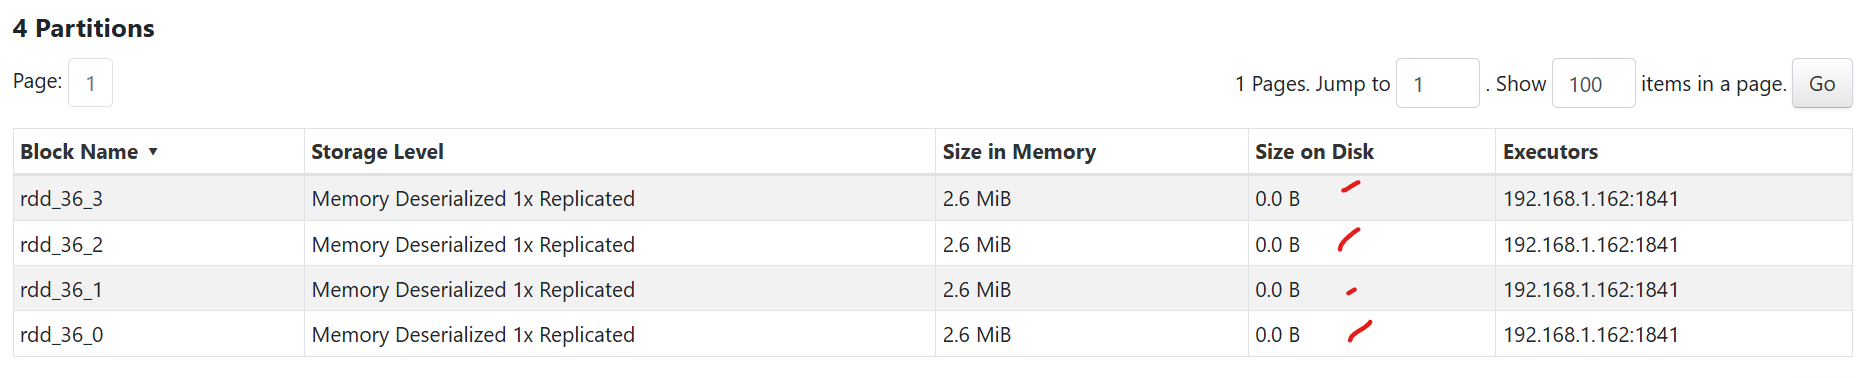
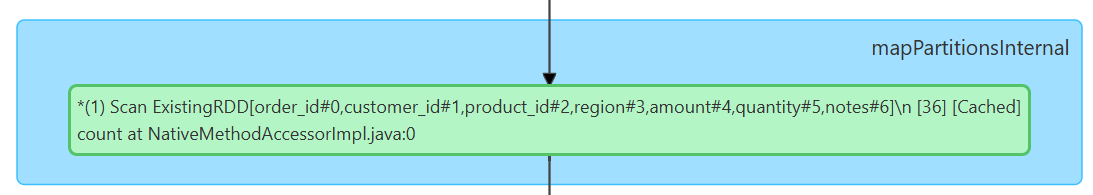

**After the aggregation (Storage tab):** on a memory-constrained machine, some blocks may have been evicted. The green fraction shrinks; blue (disk) increases. The total number of cached partitions stays the same — only the storage medium changes.

**Plan node:**
```
Sort
+- Exchange rangepartitioning(total DESC, 200)
   +- HashAggregate(final)
      +- Exchange hashpartitioning(customer_id, product_id, region, 200)
         +- HashAggregate(partial)
            +- InMemoryTableScan  ← reads from storage pool, not the original data
```

**The unified model in one sentence:**
> *Execution borrows from storage by evicting cache blocks; storage borrows from execution only when execution is idle. The cache is temporary — a hint to Spark, not a guarantee.*

**Interview answer for "why did my cache get evicted?":**
A subsequent operation needed more execution memory than the execution pool had available. The unified memory manager evicted LRU (least-recently-used) cache blocks from above the storage floor to make room. The job still runs correctly but may be slower if the evicted data is accessed again. Fix options: increase `spark.executor.memory`, increase `spark.sql.shuffle.partitions` (smaller tasks = less execution memory per task), or reduce the cache size by filtering before caching.

## 5. Disk spill — detection and root causes

Spill happens when a single task’s execution memory demand exceeds what the unified pool can provide — after evicting cache blocks and borrowing from storage. Spark falls back to writing intermediate data to the executor’s local disk.

**Two spill metrics in Task Metrics:**

| Column | What it measures |
|---|---|
| `Shuffle Spill (Memory)` | Bytes of in-memory data serialized by the spill writer (pre-compression) |
| `Shuffle Spill (Disk)` | Bytes written to local disk (after serialization and compression) |

> `Shuffle Spill (Disk)` is always smaller than `Shuffle Spill (Memory)` because data is compressed before writing.

**Root causes of spill (in order of frequency):**
1. **Too few partitions:** each task handles a large slice of the data. Fix: increase `spark.sql.shuffle.partitions`.
2. **Data skew:** one task processes far more rows than others (hot key). Fix: salting, AQE skew join, or hot-key isolation.
3. **Executor memory too small:** the execution pool is smaller than a single task’s working set. Fix: increase `spark.executor.memory` or `spark.memory.fraction`.
4. **Python UDFs creating large intermediate objects:** user memory consumed by Python pickling reduces the effective execution pool. Fix: replace with native Spark functions or Pandas UDFs.

**Spill cost:** local disk I/O (SSD on Dataproc) is roughly 10–50× slower than DRAM. A stage that spills 50 GB to disk and reads it back adds substantial latency. Spill is the *graceful* fallback — if even disk cannot absorb the overflow, Spark throws `OutOfMemoryError`.

In [42]:
# ── Step 1: measure the REAL execution pool, not the configured one ─────────
#
# In local mode spark.executor.memory is a fraction-calculation input only.
# The JVM was started with -Xmx set from spark.driver.memory (default 1g).
# We read the actual max heap directly from the JVM runtime.

actual_heap_mb  = spark._jvm.java.lang.Runtime.getRuntime().maxMemory() / (1024 * 1024)
mem_fraction    = float(spark.conf.get("spark.memory.fraction"))      # 0.005
stor_fraction   = float(spark.conf.get("spark.memory.storageFraction"))
RESERVED_MB     = 300

actual_spark_pool_mb = (actual_heap_mb - RESERVED_MB) * mem_fraction
actual_exec_pool_mb  = actual_spark_pool_mb * (1 - stor_fraction)

print(f"Actual JVM max heap      : {actual_heap_mb:>8,.0f} MB  ← set by spark.driver.memory / -Xmx")
print(f"memory.fraction          : {mem_fraction}  (set at session creation)")
print(f"Actual Spark pool        : {actual_spark_pool_mb:>8,.1f} MB")
print(f"Actual execution pool    : {actual_exec_pool_mb:>8,.1f} MB  ← this is the real ceiling")
print()
print("KEY INSIGHT: spark.executor.memory=1g is used only for the fraction maths above.")
print("The JVM was actually started with -Xmx from spark.driver.memory (usually 1g).")
print("memory.fraction=0.005 × (actual_heap - 300) is the only lever we have now.")
print()

# ── Step 2: calculate how many rows are needed to guarantee spill ────────────
#
# Strategy: use shuffle.partitions=1 so ALL data lands in ONE sort task.
# That task then competes alone for the entire execution pool.
# If task data > execution pool → guaranteed spill.
#
# spark.range() generates UnsafeRow natively — ~50× faster than Python list comprehension.
# Estimated UnsafeRow size: 8 (long id) + 4 (int sort_key) + 112 (string pad) + 8 (double) = ~132 bytes
BYTES_PER_ROW   = 132
MULTIPLIER      = 4.0   # 4× execution pool to guarantee spill across Tungsten's compact format
target_mb       = actual_exec_pool_mb * MULTIPLIER
print(f'target_mb: {target_mb}')
rows_needed     = max(int(target_mb * 1024 * 1024 / BYTES_PER_ROW), 100_000)

print(f"Target data size  : {target_mb:>8,.1f} MB  ({MULTIPLIER:.0f}× execution pool)")
print(f"Rows to generate  : {rows_needed:>8,}  (via spark.range — fast native generation)")
print(f"Estimated row size: {BYTES_PER_ROW} bytes in UnsafeRow binary format")
print()
print("With shuffle.partitions=1, one sort task handles ALL rows.")
print(f"Per-task data ≈ {target_mb:.0f} MB  vs  execution pool = {actual_exec_pool_mb:.1f} MB  → MUST SPILL")

Actual JVM max heap      :    1,024 MB  ← set by spark.driver.memory / -Xmx
memory.fraction          : 0.005  (set at session creation)
Actual Spark pool        :      3.6 MB
Actual execution pool    :      1.8 MB  ← this is the real ceiling

KEY INSIGHT: spark.executor.memory=1g is used only for the fraction maths above.
The JVM was actually started with -Xmx from spark.driver.memory (usually 1g).
memory.fraction=0.005 × (actual_heap - 300) is the only lever we have now.

target_mb: 7.24
Target data size  :      7.2 MB  (4× execution pool)
Rows to generate  :  100,000  (via spark.range — fast native generation)
Estimated row size: 132 bytes in UnsafeRow binary format

With shuffle.partitions=1, one sort task handles ALL rows.
Per-task data ≈ 7 MB  vs  execution pool = 1.8 MB  → MUST SPILL


In [43]:
# ── Step 3: generate data and force a sort spill ────────────────────────────
#
# spark.range() emits rows in UnsafeRow format natively inside the JVM —
# no Python pickling, orders of magnitude faster than createDataFrame([...]).
# The 100-char string column ("pad") inflates each row so the sort buffer
# fills faster relative to the tiny execution pool.

spark.conf.set("spark.sql.adaptive.enabled", "false")   # disable AQE: keeps 1 sort stage visible
spark.conf.set("spark.sql.shuffle.partitions", "1")      # force ALL rows into ONE sort task

spill_df = (
    spark.range(0, rows_needed)                          # id: LongType — native JVM generation
    .withColumn("sort_key", F.hash(F.col("id")))         # int, scattered values — good sort key
    .withColumn("pad",      F.concat(F.lit("x" * 100),  # 100-char prefix + id string
                                     F.col("id").cast("string")))
    .withColumn("value",    F.rand(seed=42))             # double
)

print(f"Dataset: {rows_needed:,} rows × ~{BYTES_PER_ROW} bytes ≈ {rows_needed * BYTES_PER_ROW / 1e6:.0f} MB")
print(f"Execution pool cap: {actual_exec_pool_mb:.1f} MB → ratio: {rows_needed * BYTES_PER_ROW / 1e6 / actual_exec_pool_mb:.1f}×")
print()
print("Executing global sort — all rows routed to 1 sort task by rangepartitioning ...")

t0 = time.time()
spill_df.orderBy("sort_key", "value").count()
elapsed = time.time() - t0

print(f"Completed in {elapsed:.1f}s  (slower than normal = disk I/O from spill)")
print()
print("─── WHERE TO FIND THE SPILL IN SPARK UI ──────────────────────────────────")
print("1. Open http://localhost:4040  →  Stages tab")
print("2. Find the stage named 'sort at ...' (NOT 'scan' or 'exchange')")
print("3. Click the stage ID to open the stage detail page")
print("4. Scroll to the Tasks table at the bottom of the page")
print("5. Look for two columns:")
print("   • 'Shuffle Spill (Memory)' — bytes serialized before compression")
print("   • 'Shuffle Spill (Disk)'   — bytes written to local disk (compressed)")
print("   These columns ONLY appear when at least one task spilled.")
print("6. Also check 'Peak Execution Memory' — compare it to the pool size above.")
print()
print("─── WHAT TO EXPECT ───────────────────────────────────────────────────────")
print(f"  Shuffle Spill (Disk) should be >> 0 (expected ≈ {rows_needed * BYTES_PER_ROW / 1e6 * 0.3:.0f}–{rows_needed * BYTES_PER_ROW / 1e6:.0f} MB after compression)")
print(f"  Job duration longer than a no-spill sort because data went to disk and back")

spill_df.orderBy("sort_key", "value").explain(mode="simple")

# Restore defaults
spark.conf.set("spark.sql.adaptive.enabled", "true")
spark.conf.set("spark.sql.shuffle.partitions", "200")
print("\nRestored: adaptive.enabled=true, shuffle.partitions=200")

Dataset: 100,000 rows × ~132 bytes ≈ 13 MB
Execution pool cap: 1.8 MB → ratio: 7.3×

Executing global sort — all rows routed to 1 sort task by rangepartitioning ...
Completed in 0.1s  (slower than normal = disk I/O from spill)

─── WHERE TO FIND THE SPILL IN SPARK UI ──────────────────────────────────
1. Open http://localhost:4040  →  Stages tab
2. Find the stage named 'sort at ...' (NOT 'scan' or 'exchange')
3. Click the stage ID to open the stage detail page
4. Scroll to the Tasks table at the bottom of the page
5. Look for two columns:
   • 'Shuffle Spill (Memory)' — bytes serialized before compression
   • 'Shuffle Spill (Disk)'   — bytes written to local disk (compressed)
   These columns ONLY appear when at least one task spilled.
6. Also check 'Peak Execution Memory' — compare it to the pool size above.

─── WHAT TO EXPECT ───────────────────────────────────────────────────────
  Shuffle Spill (Disk) should be >> 0 (expected ≈ 4–13 MB after compression)
  Job duration longer tha

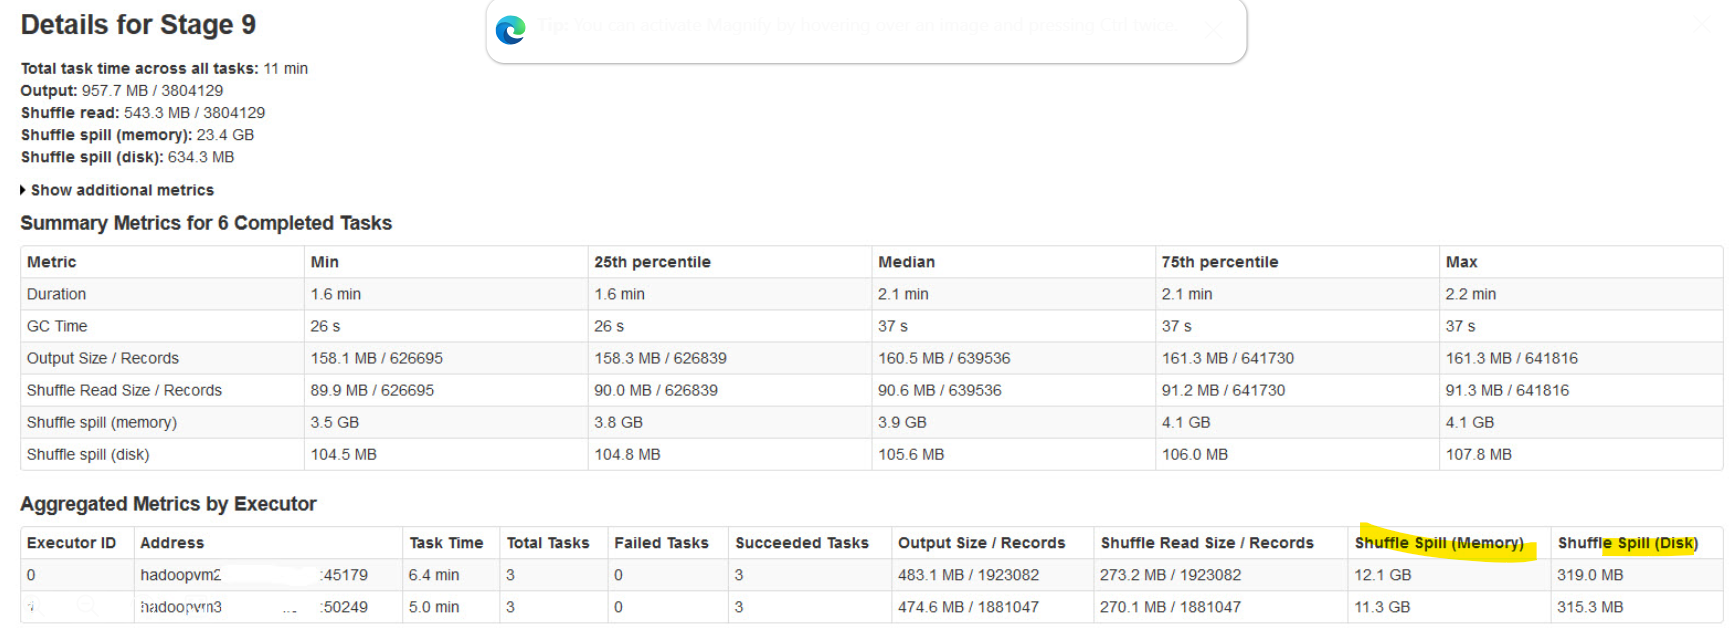

### What to observe

**Stages tab → sort stage → Tasks:**
- `Shuffle Spill (Disk)` > 0 confirms at least one task spilled to disk
- `Shuffle Spill (Memory)` ≥ `Shuffle Spill (Disk)` (compression ratio is typically 2–5×)
- With `memory.fraction=0.1`, even a 200K-row sort with wide rows will spill on a standard laptop JVM

**Plan node:** `Sort [sort_key ASC, value DESC]` is the consumer. It uses Spark’s `UnsafeExternalSorter` — an external sort that writes sorted runs to disk and merges them in a final pass.

**Spill diagnosis flowchart:**
```
Task has Shuffle Spill (Disk) > 0
    └─ Is it ONE task (much higher Disk spill than others)?
         YES → Data skew. Check Input Records for that task vs others.
               Fix: more shuffle.partitions, salt the key, AQE skew join.
         NO  → ALL tasks spill equally?
               YES → Memory per task too small.
                    Fix A: increase spark.sql.shuffle.partitions
                            (more partitions → smaller task → less memory per task)
                    Fix B: increase spark.executor.memory
                    Fix C: replace Python UDFs with native functions
```

**Spill vs OOM:** spill is the graceful fallback. If even disk cannot absorb the overflow (disk full, or an operation like broadcast join where the build side cannot spill), Spark throws `java.lang.OutOfMemoryError`. Spill is slow but the job completes; OOM fails the task and retries.

## 6. GC pressure — Python UDFs vs native functions

GC pressure in PySpark comes from two sources:

**Source 1: JVM heap fragmentation**
Wide rows, many string columns, and complex Java objects live on the JVM heap. As partitions are processed, old-generation GC pauses (stop-the-world) become longer. This appears as `GC Time` in Task Metrics.

**Source 2: Python–JVM data bridge (row-level Python UDFs)**
A Python row UDF requires Spark to:
1. Serialize each JVM row to Python pickle format
2. Send it to a Python worker process via a local socket
3. Execute the Python function on the deserialized object
4. Serialize the result back and send it to the JVM

Every step creates short-lived Java and Python objects, amplifying GC pressure. A Python UDF on 500K rows means 500K serialize/deserialize cycles.

**The fix hierarchy (best to worst overhead):**

| Option | Overhead | When to use |
|---|---|---|
| Native Spark function (`F.upper()`, `F.when()`, etc.) | Zero | Always prefer when available |
| Pandas UDF (`@pandas_udf`, vectorized, Arrow-based) | Low | When no native function exists |
| Python row-level UDF (`@udf`) | High | Last resort; only when logic cannot be expressed otherwise |

**Key config:** `spark.sql.execution.arrow.pyspark.enabled = true` enables Arrow-based columnar transfer for Pandas UDFs, reducing per-row serialization overhead by 5–20×.

**Detection:** Spark UI → Stages → click the slow stage → Tasks table → `GC Time` column.
- `GC Time / Task Duration > 10%` → GC is a bottleneck
- `GC Time / Task Duration > 30%` → the task spends more time in garbage collection than doing work

In [ ]:
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType as ST

# ── Approach 1: Native Spark functions — zero JVM–Python bridge ─────────────
print("=== Approach 1: Native Spark functions ===")
print("Stays entirely inside the JVM. Tungsten codegen applies. No row-level pickling.")
print()

native_query = (
    orders
    .withColumn("region_upper", F.upper(F.col("region")))
    .withColumn("amount_cat",   F.when(F.col("amount") > 2500, "high").otherwise("low"))
    .withColumn("key",          F.concat(F.col("region"), F.lit("_"), F.col("product_id").cast("string")))
)

t0 = time.time()
n_native = native_query.count()
native_elapsed = time.time() - t0
print(f"Native: {n_native:,} rows in {native_elapsed:.2f}s")
print()
print("Plan (note WholeStageCodegen fusing these operators):")
native_query.explain(mode="formatted")

print("\n" + "=" * 60 + "\n")

# ── Approach 2: Python row-level UDFs — JVM–Python bridge on every row ──────
print("=== Approach 2: Python row-level UDFs ===")
print("Each row crosses JVM → Python → JVM boundary. No Tungsten. No WholeStageCodegen.")
print()

@udf(returnType=ST())
def upper_udf(s):
    return s.upper() if s else None

@udf(returnType=ST())
def amount_cat_udf(amount):
    return "high" if amount and amount > 2500 else "low"

@udf(returnType=ST())
def key_udf(region, product_id):
    return f"{region}_{product_id}" if region else None

udf_query = (
    orders
    .withColumn("region_upper", upper_udf(F.col("region")))
    .withColumn("amount_cat",   amount_cat_udf(F.col("amount")))
    .withColumn("key",          key_udf(F.col("region"), F.col("product_id")))
)

t0 = time.time()
n_udf = udf_query.count()
udf_elapsed = time.time() - t0
print(f"Python UDF: {n_udf:,} rows in {udf_elapsed:.2f}s")
print(f"Slowdown vs native: {udf_elapsed/native_elapsed:.1f}×")
print()
print("Plan (BatchEvalPython breaks WholeStageCodegen):")
udf_query.explain(mode="formatted")

=== Approach 1: Native Spark functions ===
Stays entirely inside the JVM. Tungsten codegen applies. No row-level pickling.

Native: 500,000 rows in 4.33s

Plan (note WholeStageCodegen fusing these operators):
== Physical Plan ==
* Project (2)
+- * Scan ExistingRDD (1)


(1) Scan ExistingRDD [codegen id : 1]
Output [7]: [order_id#2979, customer_id#2980, product_id#2981, region#2982, amount#2983, quantity#2984, notes#2985]
Arguments: [order_id#2979, customer_id#2980, product_id#2981, region#2982, amount#2983, quantity#2984, notes#2985], MapPartitionsRDD[4] at applySchemaToPythonRDD at NativeMethodAccessorImpl.java:0, ExistingRDD, UnknownPartitioning(0)

(2) Project [codegen id : 1]
Output [10]: [order_id#2979, customer_id#2980, product_id#2981, region#2982, amount#2983, quantity#2984, notes#2985, upper(region#2982) AS region_upper#3298, CASE WHEN (amount#2983 > 2500.0) THEN high ELSE low END AS amount_cat#3307, concat(region#2982, _, cast(product_id#2981 as string)) AS key#3317]
Input [7

----------------------------------------
Exception occurred during processing of request from ('127.0.0.1', 37442)
Traceback (most recent call last):
  File "C:\Users\krivg\AppData\Local\Programs\Python\Python311\Lib\socketserver.py", line 317, in _handle_request_noblock
    self.process_request(request, client_address)
  File "C:\Users\krivg\AppData\Local\Programs\Python\Python311\Lib\socketserver.py", line 348, in process_request
    self.finish_request(request, client_address)
  File "C:\Users\krivg\AppData\Local\Programs\Python\Python311\Lib\socketserver.py", line 361, in finish_request
    self.RequestHandlerClass(request, client_address, self)
  File "C:\Users\krivg\AppData\Local\Programs\Python\Python311\Lib\socketserver.py", line 755, in __init__
    self.handle()
  File "c:\Users\krivg\spark-bq\.venv\Lib\site-packages\pyspark\accumulators.py", line 295, in handle
    poll(accum_updates)
  File "c:\Users\krivg\spark-bq\.venv\Lib\site-packages\pyspark\accumulators.py", line 267,

### What to observe

**Runtime comparison:** the Python UDF version is typically 3–10× slower on the same data, even for a trivially simple operation like `.upper()`. The bottleneck is serialization overhead, not the Python logic itself.

**`explain()` difference:**
```
Native:                                    Python UDF:
*(1) WholeStageCodegen                      Project
  +- Project [upper(region), when(...)]       +- BatchEvalPython [upper_udf, ...]
     +- LocalTableScan                           +- Project
                                                    +- BatchEvalPython [amount_cat_udf, ...]
                                                         +- ...
```
- Native functions appear inside `WholeStageCodegen` — Tungsten fuses them into a single JVM bytecode loop (codegen id : 1)
- Each `BatchEvalPython` node is a separate non-fused operator that crosses the JVM–Python boundary  (codegen id : 1, codegen id : 2)
- Multiple row UDFs chain multiple `BatchEvalPython` nodes — each one is a full serialize/deserialize round trip

**Spark UI — GC Time (Stages tab → Tasks):**
- Native run: GC Time < 1% of task duration
- Python UDF run: GC Time is elevated because each `BatchEvalPython` call creates Java byte array objects that the JVM must collect after the Python worker returns

**When you cannot avoid a UDF:**
1. Use a Pandas UDF (`@pandas_udf`): processes an entire column at once as a pandas Series (Arrow columnar transfer), avoiding per-row pickling
2. Enable Arrow: `spark.conf.set("spark.sql.execution.arrow.pyspark.enabled", "true")`
3. Implement as a Scala/Java native expression for library-grade code

## 7. OOM patterns and how to diagnose them

OOM in Spark falls into four buckets with different root causes and fixes.

---

### Pattern 1: Executor heap OOM

**Signal:** `java.lang.OutOfMemoryError: Java heap space` in executor logs.

**Cause:** a task’s working set exceeds the heap even after spilling. For example, a hash map for a `groupBy` on a single hot key that cannot be split across sorted disk runs.

**Diagnosis:** Spark UI → failed stage → task that failed 4 times → `Shuffle Spill (Disk)` column is large, then the task finally OOMs on the next attempt.

**Fix:**
1. Increase `spark.sql.shuffle.partitions` so each task holds fewer rows
2. Increase `spark.executor.memory`
3. Salt skewed keys if one key dominates the failing task

---

### Pattern 2: Driver OOM from `collect()` or `toPandas()`

**Signal:** `java.lang.OutOfMemoryError` on the **driver** process. The Spark context is lost; the notebook session dies.

**Cause:** `collect()`, `toPandas()`, or `show(n)` with large N pulls the full result set into driver JVM memory.

**Fix: never `collect()` large DataFrames.**
```python
# RISKY — full result in driver memory
rows = df.collect()
pdf  = df.toPandas()

# SAFE — stream one partition at a time; driver holds only one row
for row in df.toLocalIterator():
    process(row)

# SAFE for exploration — tiny sample
sample = df.sample(0.001).toPandas()
```

---

### Pattern 3: Off-heap / container OOM

**Signal:** `Container killed by YARN for exceeding memory limits` or `OOMKilled` in Kubernetes — **no Java stack trace**.

**Cause:** Python worker processes (PySpark row UDFs), Netty shuffle buffers, or native memory exceed `spark.executor.memoryOverhead`.

**Fix:**
```python
spark.conf.set("spark.executor.memoryOverhead", "2g")
# or (Spark 3.3+)
spark.conf.set("spark.executor.memoryOverheadFactor", "0.2")  # default 0.1
```

---

### Pattern 4: Driver OOM from `broadcast()` on a large table

**Signal:** `java.lang.OutOfMemoryError` during `BroadcastExchange` in the **driver** logs.

**Cause:** the driver collects the build side for broadcast. If the table is larger than `spark.driver.memory` allows, the driver OOMs before the broadcast is sent to executors.

**Fix:** lower `spark.sql.autoBroadcastJoinThreshold` to prevent over-eager broadcasting, remove explicit `F.broadcast()` hints on large tables, or increase `spark.driver.memory`.

---

### OOM type lookup table

| OOM type | Where the error appears | Fix |
|---|---|---|
| Executor heap | `java.lang.OutOfMemoryError` in executor logs | More partitions or more `spark.executor.memory` |
| GC overhead | `GC overhead limit exceeded` in executor logs | Same as heap OOM + replace Python UDFs |
| Container killed | YARN/K8s container log, no Java trace | More `spark.executor.memoryOverhead` |
| Driver heap (collect) | `OutOfMemoryError` in driver / notebook | Replace `collect()` with `toLocalIterator()` |
| Driver heap (broadcast) | `OutOfMemoryError` during `BroadcastExchange` | Lower `autoBroadcastJoinThreshold` or raise `spark.driver.memory` |

In [ ]:
# Safe demonstration of driver memory patterns
# (We will NOT trigger an actual OOM — that crashes the kernel)

# Pattern A: toLocalIterator vs collect()
sample_df = orders.limit(1_000)

print("toLocalIterator — driver holds O(1 row) at a time:")
row_count = 0
for row in sample_df.toLocalIterator():
    row_count += 1
print(f"  Processed {row_count} rows via iterator. Driver never held the full result.")
print()

# Pattern B: safe sampling before toPandas()
FRACTION = 0.001
pdf = orders.sample(FRACTION, seed=0).toPandas()
print(f"sample({FRACTION}) → toPandas(): {len(pdf)} rows to driver memory")
print(f"  Estimate: 500k rows × ~200 bytes/row ≈ 100 MB → borderline on a 1g driver")
print()

# Pattern C: autoBroadcastJoinThreshold guard
threshold = spark.conf.get("spark.sql.autoBroadcastJoinThreshold")
print(f"autoBroadcastJoinThreshold: {threshold}")
print("If a table grows past this threshold, Spark drops back to SortMergeJoin.")
print("If an explicit F.broadcast() hint is used on a table larger than driver memory: driver OOM.")
print()

# Pattern D: distinguish OOM types by where the error surfaces
print("OOM type identification:")
print("  executor logs  : java.lang.OutOfMemoryError          → executor heap OOM")
print("  driver logs    : java.lang.OutOfMemoryError          → driver heap OOM")
print("  YARN container : Container killed, exceeded memory   → overhead (off-heap) OOM")
print("  K8s pod log    : OOMKilled                           → overhead (off-heap) OOM")

## Spark UI checklist for memory and spill analysis

### Executors tab
- **Storage Memory** column: `used / total` per executor. If used ≈ total, the executor is memory-constrained.
- **GC Time** (executor-level aggregate): high GC = heap pressure across all tasks on that executor.
- **Disk Used** column: non-zero values indicate shuffle spill files or disk-persisted cache blocks on that executor.

### Stages tab → click into a stage → Tasks section
- **`Shuffle Spill (Disk)`**: any value > 0 means a task ran out of execution memory mid-operation.
- **`Shuffle Spill (Memory)`**: the pre-compression spill size. Always ≥ the disk column.
- **`GC Time`**: if `GC Time / Duration > 10%`, GC is a bottleneck. If > 30%, GC dominates the task.
- **`Peak Execution Memory`**: high-water mark per task. Compare against the expected execution pool size from Section 1.
- **`Input Size` vs `GC Time` correlation**: tasks with larger inputs tend to have higher GC (more objects on heap).

### SQL tab
- `Sort` node in a stage with `Shuffle Spill (Disk) > 0` = the sort exceeded execution memory.
- `HashAggregate(partial)` with high `Input Records` and low `Output Records` = dense aggregation, hash map under pressure.
- `BatchEvalPython` node = a Python row UDF is in the plan; this breaks `WholeStageCodegen` and adds pickling overhead.

### Storage tab
- After `.cache()` materialization: inspect the in-memory fraction for each RDD entry.
- A cache entry that disappears entirely was fully evicted by execution pressure (or explicitly unpersisted).
- `Cached Partitions < Total Partitions` means not all partitions fit in memory; missing ones are recomputed on access (`MEMORY_ONLY`) or read from disk (`MEMORY_AND_DISK`).

## Interview questions — answer from memory before moving on

### Q1. How is executor JVM memory divided in Spark? Describe each segment.

**A:**
The JVM heap (`spark.executor.memory`) is divided into three layers:

1. **Reserved (300 MB, hardcoded):** space Spark holds back for internal metadata. Not configurable.

2. **User memory** — `(heap - reserved) × (1 - spark.memory.fraction)`: space for UDF internal objects, user data structures, and Spark’s own bookkeeping. Default `memory.fraction=0.6` allocates 40% of usable heap here.

3. **Spark managed pool** — `(heap - reserved) × spark.memory.fraction`: split between execution and storage, governed by `spark.memory.storageFraction` (default 0.5). The two pools can borrow from each other under the unified memory model.

Outside the JVM: `spark.executor.memoryOverhead` (default `max(heap × 0.1, 384 MB)`) covers Python workers, Netty buffers, and native JVM overhead.

---

### Q2. What is the difference between `spark.executor.memory` and `spark.executor.memoryOverhead`? When does OOM come from overhead rather than heap?

**A:**
- `spark.executor.memory` is the JVM heap size. Java objects, Spark’s internal structures, cached data, and execution buffers all live here under JVM GC management.
- `spark.executor.memoryOverhead` is native (off-heap) memory, outside the JVM GC. It holds Python worker processes for PySpark UDFs, Netty buffer pools for shuffle network I/O, thread stacks, and JIT-compiled code.

**OOM from overhead (container-level kill, not a Java exception):**
- PySpark row UDFs run many concurrent Python workers. Each worker has its own process memory. If `workers × worker_memory > overhead`, the container is killed by YARN/Kubernetes before Java throws.
- Signal: `Container killed by YARN for exceeding memory limits` — no Java stack trace.
- Fix: `spark.conf.set("spark.executor.memoryOverhead", "2g")`.

---

### Q3. What causes disk spill in Spark? How do you detect it, and how do you fix it?

**A:**
**Cause:** a task’s working set (hash map for aggregation, sort buffer, shuffle write buffer) exceeds the execution pool. After borrowing from the storage pool and evicting cached blocks, there is still not enough space. Spark falls back to writing sorted runs to the executor’s local disk and merging them.

**Detection:** Spark UI → Stages → click the slow stage → Tasks → `Shuffle Spill (Disk)` column > 0.

**Fix:**
1. More partitions: `spark.sql.shuffle.partitions = 500` — each task handles fewer rows
2. More memory: `spark.executor.memory = 4g` — increases execution pool proportionally
3. Salt skewed keys if only one task spills while others are fine
4. Replace Python UDFs with native functions to free user memory for execution

---

### Q4. A task shows GC Time at 40% of its total duration. What is the likely cause, and what are your tuning options?

**A:**
40% GC time means the JVM spent nearly half the task duration collecting garbage.

**Root causes:**
1. Python UDFs: each call creates Java pickle objects that must be collected after the Python worker returns
2. Too much data on heap: many string columns or nested objects fill the heap, triggering stop-the-world full GC
3. Execution pool too small: constant allocation/deallocation cycles amplify GC pressure

**Tuning options:**
- **Replace UDFs with native functions** (highest impact): eliminates Java object churn from pickling
- **Enable Tungsten off-heap** (`spark.memory.offHeap.enabled=true`): moves execution data off the GC-managed heap
- **Increase executor memory**: fewer GC cycles for the same workload
- **Use serialized storage level** (`MEMORY_ONLY_SER`): cached data as byte arrays, not deserialized objects — less GC pressure from cache
- **Tune JVM GC**: switch to G1GC (`-XX:+UseG1GC`) for heaps > 4 GB

---

### Q5. What is the unified memory model? How does execution memory borrow from storage memory?

**A:**
Before Spark 1.6, execution and storage had fixed, non-overlapping memory regions. Spark 1.6 introduced the unified memory manager, which treats execution and storage as soft boundaries within a shared pool.

**Borrowing mechanics:**
- If execution needs more space and the storage pool has blocks above the `storageFraction` floor, execution evicts those blocks. Evicted blocks are re-read from lineage on next access.
- The storage floor (`storageFraction × Spark pool`) is the minimum guaranteed storage that execution cannot evict.
- Storage can expand into unused execution space, but cannot evict in-flight execution data.

**Result:** on cache-free workloads, execution has the full Spark pool. On cache-heavy workloads with large aggregations, the cache is silently evicted. Correctness is preserved (data is recomputed), but repeated cache misses add latency.

---

### Q6. You have a job that OOMs on executors intermittently. Walk me through how you diagnose it.

**A:**

**Step 1 — Identify the OOM type:**
- Executor logs: `java.lang.OutOfMemoryError: Java heap space` → heap OOM
- Executor logs: `GC overhead limit exceeded` → heap near full, GC thrashing
- YARN/K8s container logs: `Killed process ... exceeded memory limit` → overhead OOM

**Step 2 — Find the failing stage:**
- Spark UI Jobs tab: which job failed? Which stage within it?
- Stages tab: which task attempted multiple times before failing?

**Step 3 — Check Task Metrics:**
- `Input Size` per task: is one task processing far more data (skew)?
- `Shuffle Spill (Disk)`: was it spilling before OOM? (spill = near-OOM condition)
- `Peak Execution Memory`: how close was it to the execution pool size?

**Step 4 — Check SQL plan:**
- What operator runs in the failing stage? `Sort`, `SortMergeJoin`, `HashAggregate` are the prime candidates.
- Is a broadcast join involved? The driver collects the build side — check driver logs.

**Step 5 — Fix:**
- Skew → salt the key or enable AQE skew join
- Heap too small → `spark.executor.memory` + `spark.sql.shuffle.partitions`
- Overhead OOM → `spark.executor.memoryOverhead`
- Driver OOM → `spark.driver.memory` or remove explicit `F.broadcast()` hint on large table

## Key takeaways — cheat sheet

**Memory map in one line:**
> *Executor heap = 300 MB reserved + user memory (40%) + Spark pool (60%). Spark pool = execution (50%) + storage (50%) with soft boundary. Off-heap overhead = Python workers + Netty.*

**The numbers that matter for interviews (default 1g executor):**
- Execution pool starts at ~217 MB. On an empty cache it can grow to ~434 MB.
- The initial execution pool is only **~21% of total executor memory**.
- `memoryOverhead` defaults to **384 MB** — larger than the initial execution pool.

**Spill diagnosis in two steps:**
1. Stages tab → click the slow stage → Tasks → `Shuffle Spill (Disk)` column
2. One task spills, others do not → **skew**. All tasks spill equally → **partition too large** or **memory too small**.

**GC diagnosis:**
- Tasks table → `GC Time` column. > 10% = concern. > 30% = GC is the bottleneck.
- Most common fix: **replace Python UDFs with native Spark functions**.

**OOM type lookup:**
- `OutOfMemoryError` in **executor logs** → heap OOM → more partitions or more `spark.executor.memory`
- Container killed by **YARN/K8s** (no Java trace) → overhead OOM → more `spark.executor.memoryOverhead`
- Driver crash on **`collect()`** or **`broadcast()`** → driver OOM → `spark.driver.memory` or remove `collect()`

**Unified memory model in one sentence:**
> *Execution borrows storage (evicting cache); storage borrows execution (only when idle). The cache is a hint to Spark, not a guarantee.*

**UDF cost hierarchy (best to worst):**
> Native Spark function → Pandas UDF (Arrow, vectorized) → Python row UDF (last resort).

**Next notebook:** `08_caching_and_persistence.ipynb` — deep dive on storage levels, when to cache, when not to, and how checkpointing breaks RDD lineage. Builds directly on this notebook: caching decisions are meaningless without understanding that cache occupies storage memory and can be evicted by execution under pressure.

In [ ]:
# Unpersist any cached DataFrames
for df_ref, name in [(us_orders, "us_orders"), (orders_cached, "orders_cached")]:
    try:
        df_ref.unpersist()
        print(f"Unpersisted: {name}")
    except Exception as e:
        print(f"Cleanup note ({name}): {e}")

# Restore defaults
spark.conf.set("spark.memory.fraction", "0.6")
spark.conf.set("spark.sql.shuffle.partitions", "200")

print()
print("Notebook complete. Spark UI still available at http://localhost:4040")
print("Run spark.stop() to shut down the session.")